In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import HuberRegressor
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.impute import SimpleImputer

# 1. Load Data
df_matches = pd.read_csv("./data/gold_match.csv")
df_promo = pd.read_csv("./data/gold_match_context.csv")
df_tickets = pd.read_csv("./data/gold_match_ticket.csv")

# 2. Merge and Filter
df = pd.merge(df_matches, df_promo, on='match_id', how='left', suffixes=('', '_drop'))
df = pd.merge(df, df_tickets, on='match_id', how='left', suffixes=('', '_drop'))
df = df.filter(regex='^(?!.*_drop)')
df = df[df['is_home_match'] == True].copy()

# 3. Feature Engineering
df['hour'] = pd.to_datetime(df['kickoff_time_local']).dt.hour
df['match_date'] = pd.to_datetime(df['match_date'])
df = df.sort_values('match_date')

df['matchday_num'] = df.groupby('season').cumcount() + 1
df['season_max_day'] = df.groupby('season')['matchday_num'].transform('max')
df['season_intensity'] = (df['matchday_num'] - (df['season_max_day'] / 2)).abs()
df['season_intensity_sq'] = df['season_intensity']**2

# B. Home Team Form (Last 3 Home Games)
# Did the fans leave the last game happy? 
df['points_earned'] = np.where(df['goals_home_ft'] > df['goals_away_ft'], 3, 
                               np.where(df['goals_home_ft'] == df['goals_away_ft'], 1, 0))

# .shift(1) is CRITICAL so the model doesn't know the result of the game it's predicting
df['home_form_recent'] = df.groupby('season')['points_earned'].transform(
    lambda x: x.rolling(window=3, min_periods=1).mean().shift(1)
).fillna(1.0) # Default to a draw average if it's the season opener


train_idx = int(len(df) * 0.8)
avg_attendance = df.iloc[:train_idx]['tickets_scanned'].mean()
team_means = df.iloc[:train_idx].groupby('away_team')['tickets_scanned'].mean()

def get_tier(val):
    if val > avg_attendance * 1.1: return 3 # High interest
    if val < avg_attendance * 0.9: return 1 # Low interest
    return 2

tier_map = team_means.apply(get_tier).to_dict()
df['opponent_tier'] = df['away_team'].map(tier_map).fillna(2)

df['weather_misery_index'] = df['weather_precipitation_mm'] * (20 - df['weather_temp_max_c']).clip(lower=1)

df['promo_ratio'] = df['promo_tickets_total'] / df['tickets_sold_total']

df['away_fan_proxy'] = df['opponent_tier'].map({1: 50, 2: 250, 3: 500})

df['match_hype'] = (df['season_intensity']**2) * df['home_form_recent']

# 4. Split Data (Keep shuffle=True for small N=71 to get a mix of seasons)
df_train, df_test = train_test_split(df, test_size=0.2, random_state=42, shuffle=True)

df_train = df_train.copy()
df_test = df_test.copy()

# 6. Simplified Variable Selection
# For N=71, we shouldn't use too many categories. 
num_cols = [
    'tickets_sold_total', 
    'away_fan_proxy',
    'match_hype'
]

# 7. Final X and y assignment
X_train = df_train[num_cols]
y_train = df_train['tickets_scanned']
X_test = df_test[num_cols]
y_test = df_test['tickets_scanned']


model_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('regressor', HuberRegressor())
])

# 9. Train and Evaluate
model_pipeline.fit(X_train, y_train)
train_preds = model_pipeline.predict(X_train)
test_preds = model_pipeline.predict(X_test)

# 10. Cross-Validation (More reliable for N=71)
cv_scores = cross_val_score(model_pipeline, X_train, y_train, cv=5, scoring='r2')

train_mae = mean_absolute_error(y_train, train_preds)
test_mae = mean_absolute_error(y_test, test_preds)

print(f"--- Small Dataset Results (N={len(df)}) ---")
print(f"Training MAE: {train_mae:.2f}")
print(f"Test MAE:     {test_mae:.2f}")
print(f"Difference:   {abs(train_mae - test_mae):.2f}")
print("-" * 30)
print(f"R2 Score (Test Set): {r2_score(y_test, test_preds):.2f}")
print(f"Average CV R2 Score: {cv_scores.mean():.2f}")

--- Small Dataset Results (N=71) ---
Training MAE: 1296.17
Test MAE:     925.63
Difference:   370.53
------------------------------
R2 Score (Test Set): 0.53
Average CV R2 Score: 0.25


C:\Users\nterh\AppData\Local\Temp\ipykernel_27432\2461494109.py:23: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['hour'] = pd.to_datetime(df['kickoff_time_local']).dt.hour


In [62]:
# Create a summary of the 14 test games
test_results = df_test.copy()
test_results['Predicted'] = test_preds
test_results['Error'] = test_results['tickets_scanned'] - test_results['Predicted']
test_results['Abs_Error'] = test_results['Error'].abs()

# Sort by the biggest misses
biggest_misses = test_results[['match_date', 'away_team', 'tickets_scanned', 'Predicted', 'Error']].sort_values(by='Error', ascending=False)

print("--- Top 5 Under-estimations (Model guessed too low) ---")
print(biggest_misses.head(5))

print("\n--- Top 5 Over-estimations (Model guessed too high) ---")
print(biggest_misses.tail(5))

--- Top 5 Under-estimations (Model guessed too low) ---
   match_date     away_team  tickets_scanned    Predicted        Error
63 2024-03-17      Mechelen          11069.0  7829.611421  3239.388579
26 2023-02-26       Antwerp           9331.0  7633.945490  1697.054510
11 2022-10-15          Genk           7238.0  6456.560521   781.439479
44 2023-10-22  Sint-Truiden           7784.0  7479.869159   304.130841
37 2023-08-18       Antwerp           8577.0  8342.402142   234.597858

--- Top 5 Over-estimations (Model guessed too high) ---
    match_date     away_team  tickets_scanned    Predicted        Error
22  2023-01-28  Sint-Truiden           6399.0  7089.447652  -690.447652
20  2023-01-17         Eupen           3537.0  4532.299914  -995.299914
93  2024-12-27     Beerschot           6655.0  7788.632683 -1133.632683
66  2024-04-14          Gent           4936.0  6467.607339 -1531.607339
122 2025-09-26    Anderlecht           6977.0  9322.616701 -2345.616701


C:\Users\nterh\AppData\Local\Temp\ipykernel_27432\3791280622.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(result.importances[sorted_idx].T, vert=False, labels=np.array(num_cols)[sorted_idx])


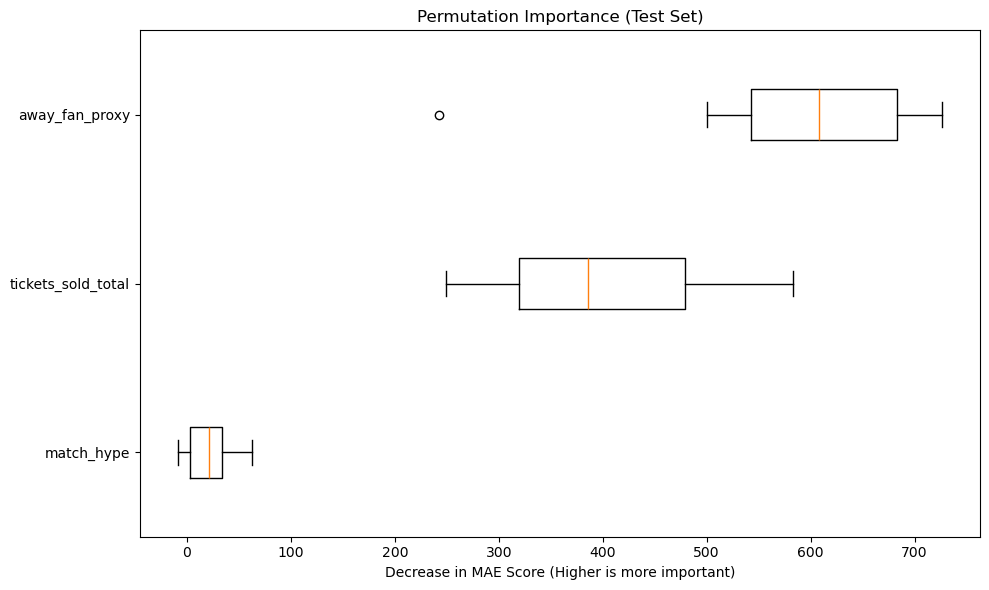

In [60]:
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt

result = permutation_importance(
    model_pipeline, X_test, y_test, n_repeats=10, random_state=42, scoring='neg_mean_absolute_error'
)

# Organize and Plot
sorted_idx = result.importances_mean.argsort()
plt.figure(figsize=(10, 6))
plt.boxplot(result.importances[sorted_idx].T, vert=False, labels=np.array(num_cols)[sorted_idx])
plt.title("Permutation Importance (Test Set)")
plt.xlabel("Decrease in MAE Score (Higher is more important)")
plt.tight_layout()
plt.show()

In [63]:
# 1. Get your best predictions
best_model = model_pipeline # Your base Huber model
df_test['preds'] = best_model.predict(X_test)
df_test['error'] = df_test['tickets_scanned'] - df_test['preds']

# 2. Find the "Disasters" (The games that hurt your MAE)
# Sort by absolute error to see the biggest misses
df_test['abs_error'] = df_test['error'].abs()
print("Top 5 Matches where the model failed:")
print(df_test.sort_values('abs_error', ascending=False)[['match_date', 'away_team', 'tickets_scanned', 'preds', 'error']].head(5))

Top 5 Matches where the model failed:
    match_date   away_team  tickets_scanned        preds        error
63  2024-03-17    Mechelen          11069.0  7829.611421  3239.388579
122 2025-09-26  Anderlecht           6977.0  9322.616701 -2345.616701
26  2023-02-26     Antwerp           9331.0  7633.945490  1697.054510
66  2024-04-14        Gent           4936.0  6467.607339 -1531.607339
93  2024-12-27   Beerschot           6655.0  7788.632683 -1133.632683
